<a href="https://colab.research.google.com/github/yagmurogetman/DSA210-Project/blob/main/ML_Method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import seaborn as sns

In [13]:
import pandas as pd

# Load the datasets
df_cuisine = pd.read_csv('global_cuisines_master_final.csv')
df_temp = pd.read_csv('standardized_temperature.csv')
df_hum = pd.read_csv('standardized_humidity.csv')
df_precip = pd.read_csv('standardized_precipitation.csv')

print("Cuisine Dataset Head:")
print(df_cuisine.head())

Cuisine Dataset Head:
  Country_Code Country_Name     Dish_Name           Main_Ingredient
0          AFG  Afghanistan  Kabuli Pulao         Rice/Lamb/Carrots
1          ALB      Albania     Tavë Kosi          Lamb/Yogurt/Rice
2          DZA      Algeria      Couscous  Semolina/Vegetables/Meat
3          ARG    Argentina         Asado                 Beef/Salt
4          AUS    Australia      Meat Pie        Minced Meat/Pastry


In [14]:
# Extracting only relevant columns and renaming 'Value' to specific climate factors
df_temp = df_temp[['Country_Code', 'Value']].rename(columns={'Value': 'Temperature'})
df_hum = df_hum[['Country_Code', 'Value']].rename(columns={'Value': 'Humidity'})
df_precip = df_precip[['Country_Code', 'Value']].rename(columns={'Value': 'Precipitation'})

print("Climate data columns standardized.")

Climate data columns standardized.


In [15]:
# Merging all dataframes on 'Country_Code'
df_master = df_cuisine.merge(df_temp, on='Country_Code') \
                      .merge(df_hum, on='Country_Code') \
                      .merge(df_precip, on='Country_Code')

# Drop potential duplicate columns if they exist
df_master = df_master.loc[:,~df_master.columns.duplicated()]

print(f"Master dataset created with {len(df_master)} countries.")

Master dataset created with 66 countries.


In [16]:
# Splitting ingredients and converting them into dummy variables
ingredients_binary = df_master['Main_Ingredient'].str.get_dummies(sep='/')

# Concatenate the binary ingredient columns with the climate data
df_processed = pd.concat([df_master, ingredients_binary], axis=1)

print("Ingredients successfully tokenized into binary features.")

Ingredients successfully tokenized into binary features.


In [17]:
# Checking for null values
if df_processed.isnull().values.any():
    df_processed = df_processed.fillna(0) # Filling missing ingredient flags with 0
    print("Missing values handled.")

# Saving the final processed dataset
df_processed.to_csv('processed_culinary_climate_data.csv', index=False)
print("Processing complete. File saved as 'processed_culinary_climate_data.csv'.")

Processing complete. File saved as 'processed_culinary_climate_data.csv'.


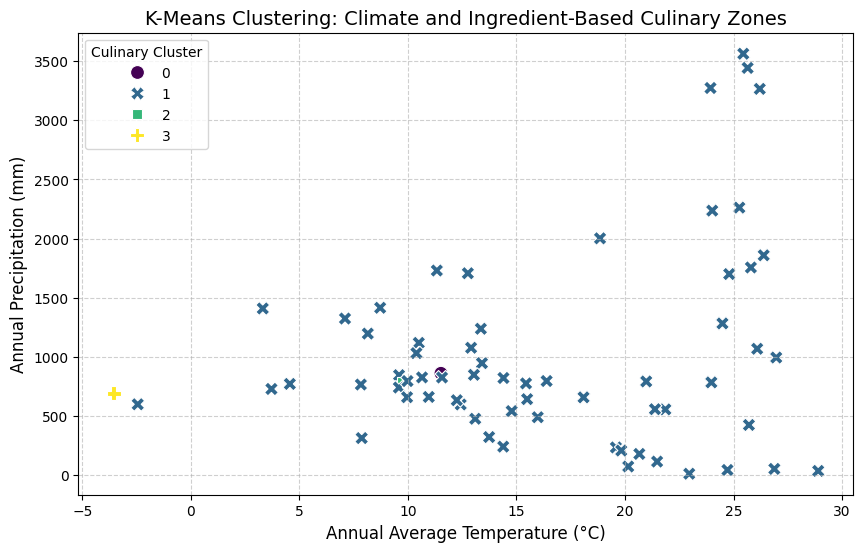

Sample countries grouped by Cluster:
   Country_Name  Cluster
0   Afghanistan        1
1       Albania        1
2       Algeria        1
3     Argentina        1
4     Australia        1
5       Austria        1
6    Azerbaijan        1
7    Bangladesh        1
8       Belgium        0
9        Brazil        1
10       Canada        3
11        Chile        1
12        China        1
13     Colombia        1
14      Croatia        1

Cluster Means (Climate Comparison):
         Temperature  Precipitation  Humidity
Cluster                                      
0          11.520000      860.55000  75.12000
1          16.480476     1004.72619  65.30254
2           9.720000      791.13000  80.46000
3          -3.560000      691.61000  73.94000


In [20]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Select features for clustering
# We extract numerical columns (Climate metrics + Binary Ingredient features)
ingredient_features = df_processed.select_dtypes(include=['float64', 'int64']).drop(columns=['Temperature', 'Humidity', 'Precipitation'], errors='ignore')
climate_features = df_processed[['Temperature', 'Humidity', 'Precipitation']]

# Combine climate and ingredient data into one feature matrix
X = pd.concat([climate_features, ingredient_features], axis=1)

# Step 2: Feature Scaling (Crucial for K-Means performance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Model Initialization
# We define 4 distinct "Climate-Gastro Zones"
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_processed['Cluster'] = kmeans.fit_predict(X_scaled)

# Step 4: Visualization (Clustering based on Temperature vs. Precipitation)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_processed,
    x='Temperature',
    y='Precipitation',
    hue='Cluster',
    palette='viridis',
    s=100,
    style='Cluster'
)

plt.title('K-Means Clustering: Climate and Ingredient-Based Culinary Zones', fontsize=14)
plt.xlabel('Annual Average Temperature (°C)', fontsize=12)
plt.ylabel('Annual Precipitation (mm)', fontsize=12)
plt.legend(title='Culinary Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Step 5: Output sample results
print("Sample countries grouped by Cluster:")
print(df_processed[['Country_Name', 'Cluster']].head(15))

# Optional: Check cluster characteristics
print("\nCluster Means (Climate Comparison):")
print(df_processed.groupby('Cluster')[['Temperature', 'Precipitation', 'Humidity']].mean())

--- MACHINE LEARNING MODEL PERFORMANCE ---
Model Accuracy: 0.50

Detailed Classification Report:
              precision    recall  f1-score   support

     No Rice       0.67      0.60      0.63        10
        Rice       0.20      0.25      0.22         4

    accuracy                           0.50        14
   macro avg       0.43      0.42      0.43        14
weighted avg       0.53      0.50      0.51        14



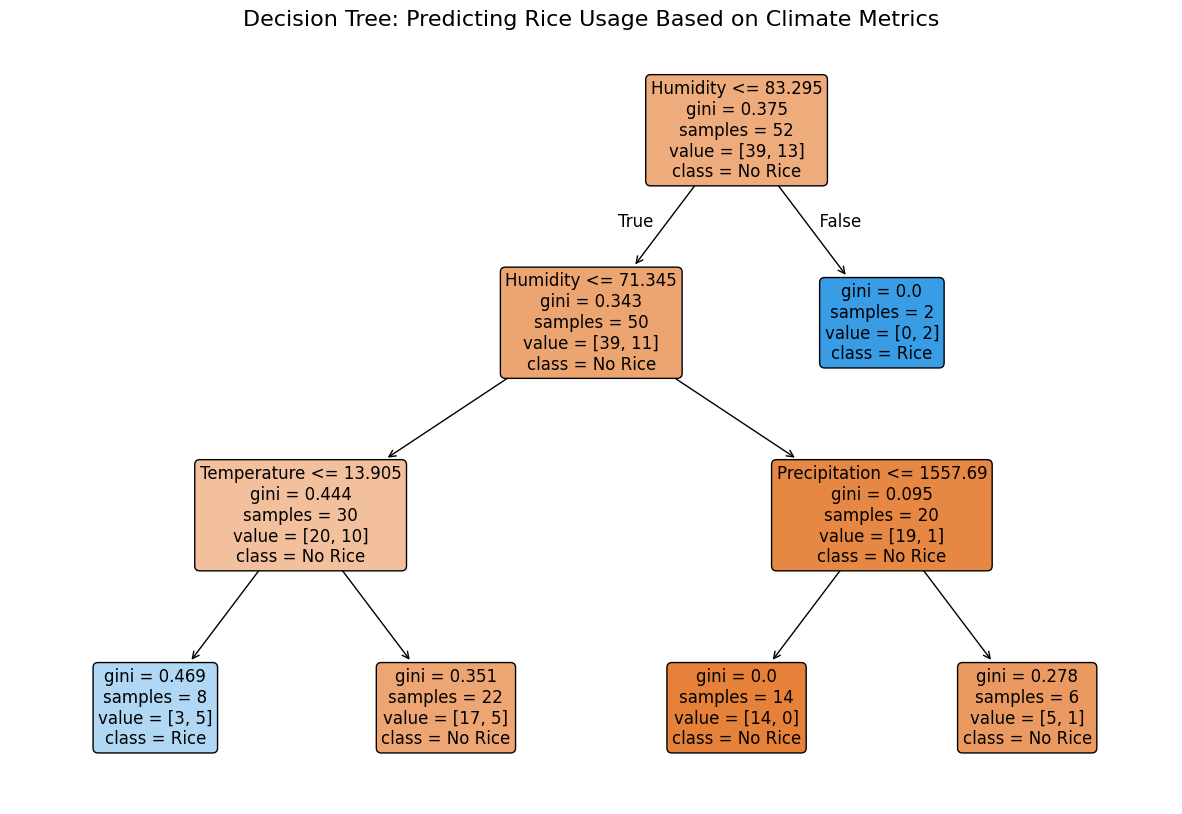


Feature Importance (Which climate factor matters most?):
Humidity         0.671275
Temperature      0.292014
Precipitation    0.036710
dtype: float64


In [21]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# Step 1: Define Features and Target
# Target variable: Is Rice a main ingredient? (1 = Yes, 0 = No)
# Input features: Temperature, Humidity, Precipitation
X_ml = df_processed[['Temperature', 'Humidity', 'Precipitation']]
y_ml = df_processed['Rice']

# Step 2: Split data into Training and Testing sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_ml, y_ml, test_size=0.2, random_state=42)

# Step 3: Initialize and Train the Decision Tree Model
# We limit max_depth to 3 to keep the tree readable and prevent overfitting
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

# Step 4: Model Prediction and Performance Analysis
y_pred = dt_model.predict(X_test)

print("--- MACHINE LEARNING MODEL PERFORMANCE ---")
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Rice', 'Rice']))

# Step 5: Visualizing the Decision Tree
plt.figure(figsize=(15, 10))
plot_tree(
    dt_model,
    feature_names=X_ml.columns,
    class_names=['No Rice', 'Rice'],
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title("Decision Tree: Predicting Rice Usage Based on Climate Metrics", fontsize=16)
plt.show()

# Step 6: Feature Importance
# This shows which climate factor is the most "powerful" in determining the cuisine
importance = pd.Series(dt_model.feature_importances_, index=X_ml.columns)
print("\nFeature Importance (Which climate factor matters most?):")
print(importance.sort_values(ascending=False))